In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gsw
import os

from scipy.integrate import trapezoid
from scipy.stats import linregress

from amocatlas import read
from correlation_trends import geostrophy, filters

In [2]:
figpath = "../figures/"

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)

#MOC = transports.MOC
#TRANS_FC = transports.TRANS_FC
#TRANS_EKMAN = transports.TRANS_FC
TRANS_UMO = transports.TRANS_UMO

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)
ts = read.rapid(file_list=["ts_gridded.nc"], transport_only=False)
# 26N overturning in density coordinates: MOC_SIGMA0
#mt = read.rapid(file_list=["meridional_transports.nc"], transport_only=False)
# 47N NOAC overturning (monthly): MOC_SIGMA0
#noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity



In [5]:
transport = geostrophy.geostrophy_jakob(ts)
# introduce 10 day lowpass to match RAPID filtering
filtered_transport_geostrophy = filters.tukey_lowpass(transport,window = 20)

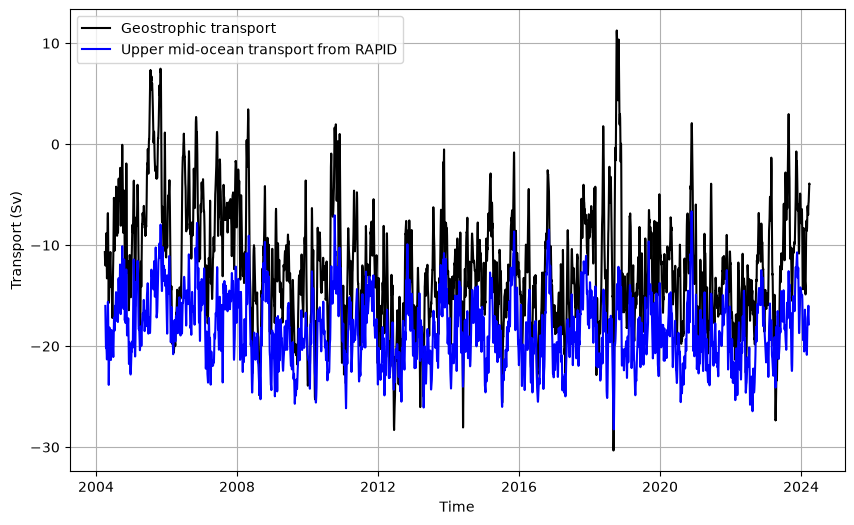

In [6]:
plt.figure(figsize=[10,6])
plt.plot(TRANS_UMO["TIME"],filtered_transport_geostrophy, color ="k",label = "Geostrophic transport")
plt.plot(TRANS_UMO["TIME"],TRANS_UMO,color = "blue", label = "Upper mid-ocean transport from RAPID")
plt.grid()
plt.xlabel("Time")
plt.ylabel("Transport (Sv)")
plt.legend()
plt.savefig(figpath + "UMO_geostrophy.png")

In [7]:
# we skip the first and last 10 time data points as they are removed in the 10 day lowpass filtering
finite_transport = np.isfinite(TRANS_UMO.values)
r = np.corrcoef(filtered_transport_geostrophy[finite_transport], TRANS_UMO.values[finite_transport])
r_unfiltered = np.corrcoef(transport[finite_transport], TRANS_UMO.values[finite_transport])

regression_line = linregress(filtered_transport_geostrophy[finite_transport],TRANS_UMO[finite_transport])
print(f"The correlation coefficient between the UMO transport from RAPID and our 10-day lowpassed calculated geostrophic transport is {r[0,1]:.3f}")
print(f"The correlation coefficient between the UMO transport from RAPID and our unfiltered calculated geostrophic transport is {r_unfiltered[0,1]:.3f}")

The correlation coefficient between the UMO transport from RAPID and our 10-day lowpassed calculated geostrophic transport is 0.773
The correlation coefficient between the UMO transport from RAPID and our unfiltered calculated geostrophic transport is 0.751


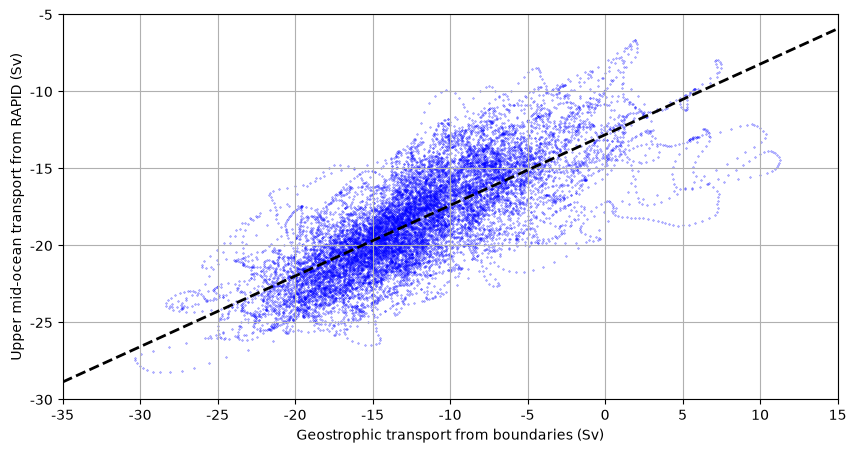

In [8]:
plt.figure(figsize=(10,5))
plt.scatter(filtered_transport_geostrophy, TRANS_UMO, c = "blue", marker = "x", s = 1, alpha = 0.3)
plt.plot(
    np.arange(-35,20,5),
    np.arange(-35,20,5)*regression_line.slope + regression_line.intercept, 
    ls = "--",
    color = "k",
    lw = 2
    )
plt.xlabel("Geostrophic transport from boundaries (Sv)")
plt.ylabel("Upper mid-ocean transport from RAPID (Sv)")
plt.grid()
plt.ylim(-30,-5)
plt.xlim(-35,15)
plt.xticks(np.arange(-35,20,5),np.arange(-35,20,5))
plt.yticks(np.arange(-30,0,5),np.arange(-30,0,5))
plt.savefig(figpath + "scatter_geostrophy_UMO.png")
plt.show()